# 图像分类课程设计——基于 ResNet18 的深度伪造检测

## 项目背景

随着深度学习生成模型（Deepseek、GPT、LLaMA 等）的爆发式应用，AI 技术已深度融入金融、
医疗、智能终端等核心领域。与此同时，深度伪造身份攻击（Deepfake）也随之成为重大安全威胁。
本实验基于 **2025 全球 AI 攻防挑战赛——OpenMMSec 多模态AI安全基准数据集** 的图像子集，
利用预训练 ResNet18 实现图像级别的深度伪造检测。

### 技术路线
由于原始数据为无标签图像，采用"预训练特征提取 → K-means 聚类 → 伪标签 → 迁移学习"的流程：
1. 使用 ImageNet 预训练的 ResNet18 提取图像特征
2. K-means 聚类为 2 类（真实/伪造），生成伪标签
3. 基于伪标签训练分类器
4. 评估并可视化结果

### 实验环境
- 框架：PyTorch
- 预训练模型：ResNet18（torchvision）
- 运行方式：CPU 兼容

In [42]:
# =============================================
# Cell 1: 安装依赖（首次运行需取消注释）
# =============================================
# 若在 Jupyter 中运行提示缺少包，取消下面注释
# !pip install torch torchvision matplotlib numpy scikit-learn Pillow tqdm

import os
import copy
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('设备:', 'CUDA' if torch.cuda.is_available() else 'CPU (兼容)')

PyTorch version: 2.8.0
设备: CPU (兼容)


In [ ]:
# =============================================
# Cell 2: 超参数设置
# =============================================
DATA_DIR = './0'        # 图像目录（平铺所有 jpg）
BATCH_SIZE = 32          # 批次大小
EPOCHS = 3               # 训练轮数
IMG_SIZE = 224           # ResNet 输入尺寸
N_CLUSTERS = 2           # 聚类数（真实/伪造 二分类）
TEST_SPLIT = 0.2         # 测试集比例
LR = 0.001               # 学习率
DEVICE = torch.device('cpu')  # CPU 兼容
RANDOM_SEED = 42
MAX_IMAGES = None

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'数据目录: {os.path.abspath(DATA_DIR)}')
print(f'聚类数: {N_CLUSTERS}（二分类: 真实 vs 伪造）')
print(f'最大样本数: {MAX_IMAGES if MAX_IMAGES else "全部"}')

数据目录: /Users/sandw1ch/Documents/VS/0
聚类数: 2（二分类: 真实 vs 伪造）
最大样本数: 25000


In [44]:
# =============================================
# Cell 3: 数据预处理
# =============================================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('预处理定义完成: Resize(224x224) → Tensor → Normalize(ImageNet)')

预处理定义完成: Resize(224x224) → Tensor → Normalize(ImageNet)


In [45]:
# =============================================
# Cell 4: 自定义 Dataset（读取平铺的 jpg 文件）
# =============================================
class ImageFolderFlat(Dataset):
    """读取单目录下所有图片，不使用子目录类结构"""
    def __init__(self, root, transform=None, max_images=None):
        self.root = root
        self.transform = transform
        all_files = sorted([
            os.path.join(root, f) for f in os.listdir(root)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        if max_images and max_images < len(all_files):
            # 均匀采样以保证覆盖各类
            indices = np.linspace(0, len(all_files)-1, max_images, dtype=int)
            self.samples = [all_files[i] for i in indices]
        else:
            self.samples = all_files
        print(f'共加载 {len(self.samples)} 张图片（总库 {len(all_files)} 张）')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, idx  # 返回 idx 用于后续映射标签

full_dataset = ImageFolderFlat(DATA_DIR, transform=transform, max_images=MAX_IMAGES)

共加载 25000 张图片（总库 25000 张）


In [46]:
# =============================================
# Cell 5: 加载预训练 ResNet18 并提取特征
# =============================================
feature_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# 去掉最后一层分类头，输出特征向量 (512-dim)
feature_model = nn.Sequential(*list(feature_model.children())[:-1])
feature_model = feature_model.to(DEVICE)
feature_model.eval()

loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('开始提取特征...')
features = []
with torch.no_grad():
    for images, _ in tqdm(loader):
        feats = feature_model(images.to(DEVICE))  # (B, 512, 1, 1)
        feats = feats.view(feats.size(0), -1)      # (B, 512)
        features.append(feats.cpu().numpy())

features = np.concatenate(features, axis=0)
print(f'特征矩阵形状: {features.shape}（{features.shape[0]} 张图 × {features.shape[1]} 维特征）')

开始提取特征...


100%|██████████| 782/782 [09:49<00:00,  1.33it/s]

特征矩阵形状: (25000, 512)（25000 张图 × 512 维特征）


正在执行 K-means 聚类 (K=2)...
  类别 0: 12844 张 (51.4%)
  类别 1: 12156 张 (48.6%)
正在 t-SNE 降维...


/var/folders/04/9b16lfb902g78g4mjddjwdl40000gn/T/ipykernel_3607/682396262.py:28: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_visualization.png', dpi=150)
/var/folders/04/9b16lfb902g78g4mjddjwdl40000gn/T/ipykernel_3607/682396262.py:28: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_visualization.png', dpi=150)
/var/folders/04/9b16lfb902g78g4mjddjwdl40000gn/T/ipykernel_3607/682396262.py:28: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_visualization.png', dpi=150)
/var/folders/04/9b16lfb902g78g4mjddjwdl40000gn/T/ipykernel_3607/682396262.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_visualization.png', dpi=150)
/var/folders/04/9b16lfb902g78g4mjddjwdl40000gn/T/ipykernel_3607/682396262.py:28: UserWarning: Glyph 

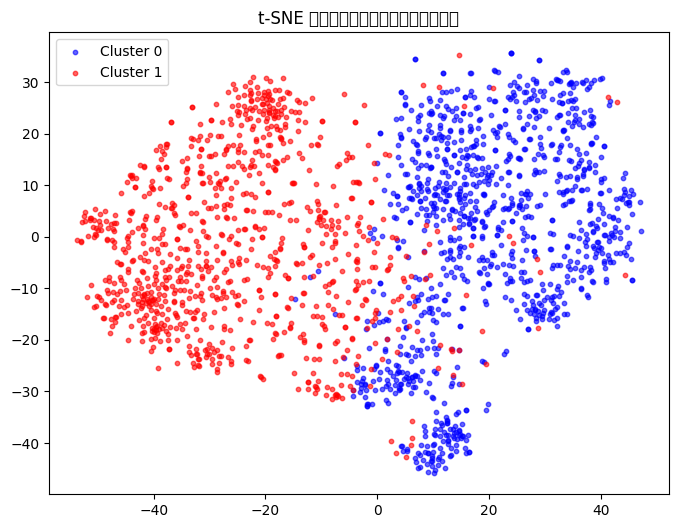

聚类可视化已保存: cluster_visualization.png


In [47]:
# =============================================
# Cell 6: K-means 聚类生成伪标签
# =============================================
print(f'正在执行 K-means 聚类 (K={N_CLUSTERS})...')
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
pseudo_labels = kmeans.fit_predict(features)

# 统计各类别数量
unique, counts = np.unique(pseudo_labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  类别 {cls}: {cnt} 张 ({cnt/len(pseudo_labels)*100:.1f}%)')

# t-SNE 降维可视化（仅取 2000 张避免过慢）
n_vis = min(2000, len(features))
idx_sample = np.random.choice(len(features), n_vis, replace=False)
print('正在 t-SNE 降维...')
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30)
feats_2d = tsne.fit_transform(features[idx_sample])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red']
for cls in range(N_CLUSTERS):
    mask = pseudo_labels[idx_sample] == cls
    plt.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                c=colors[cls], label=f'Cluster {cls}', alpha=0.6, s=10)
plt.title('t-SNE 可视化（特征空间中的聚类分布）')
plt.legend()
plt.savefig('cluster_visualization.png', dpi=150)
plt.show()
print('聚类可视化已保存: cluster_visualization.png')

In [48]:
# =============================================
# Cell 7: 创建带伪标签的数据集并划分
# =============================================
class LabeledDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        # 确保标签为 int64（PyTorch 的 CrossEntropyLoss 要求 Long 类型）
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

# 训练集用数据增强，测试集不变
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 划分训练/测试集（分层抽样保证类别分布一致）
from sklearn.model_selection import train_test_split

paths = full_dataset.samples
train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, pseudo_labels, test_size=TEST_SPLIT,
    random_state=RANDOM_SEED, stratify=pseudo_labels
)

train_dataset = LabeledDataset(train_paths, train_labels, transform=train_transform)
test_dataset = LabeledDataset(test_paths, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'训练集: {len(train_dataset)} 张')
print(f'测试集: {len(test_dataset)} 张')
print(f'类别数: {N_CLUSTERS}')

训练集: 20000 张
测试集: 5000 张
类别数: 2


In [49]:
# =============================================
# Cell 8: 构建 ResNet18 分类模型
# =============================================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, N_CLUSTERS)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f'ResNet18 构建完成')
print(f'  全连接层: {in_features} → {N_CLUSTERS}')

ResNet18 构建完成
  全连接层: 512 → 2


In [50]:
# =============================================
# Cell 9: 训练与评估函数
# =============================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

print('训练/评估函数定义完成')

训练/评估函数定义完成


In [51]:
# =============================================
# Cell 10: 执行训练
# =============================================
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print(f'开始训练 (Epochs={EPOCHS}, Batch={BATCH_SIZE}, LR={LR})...\n')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f'Epoch {epoch:2d}/{EPOCHS}  '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  '
          f'Test Loss: {test_loss:.4f}  Acc: {test_acc*100:.2f}%')

print(f'\n训练完成！最终测试准确率: {test_accs[-1]*100:.2f}%')

开始训练 (Epochs=5, Batch=32, LR=0.001)...

Epoch  1/5  Train Loss: 0.1662  Acc: 93.84%  Test Loss: 0.1196  Acc: 95.36%


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

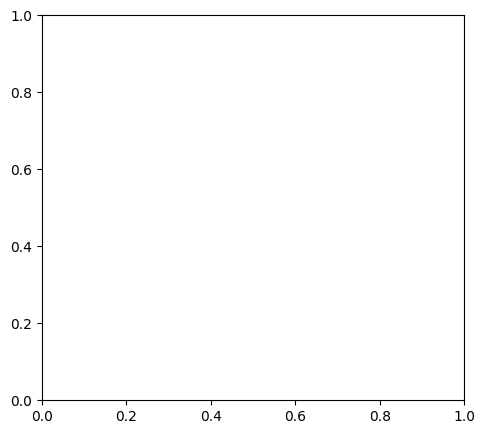

In [ ]:
# =============================================
# Cell 11: Loss 与 Accuracy 曲线
# =============================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, 'b-o', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, 'r-o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss 曲线')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accs, 'b-o', label='Training Accuracy')
plt.plot(range(1, EPOCHS + 1), test_accs, 'r-o', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy 曲线')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'最高测试准确率: {max(test_accs)*100:.2f}%')

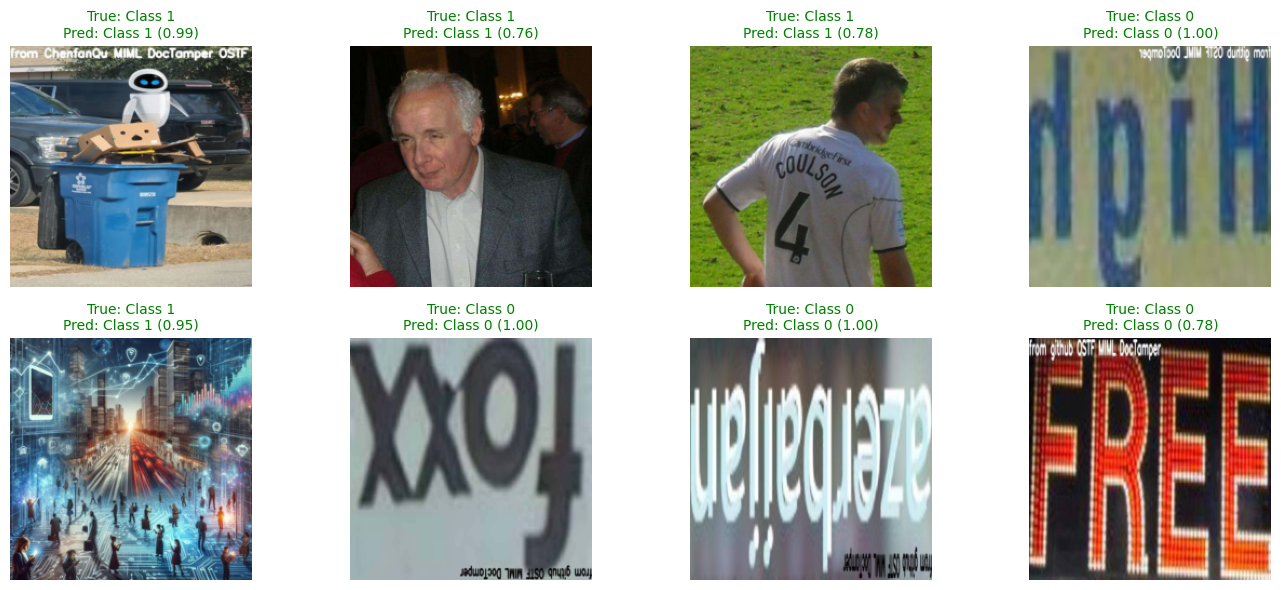

展示批次的准确率: 28/32 = 87.50%


In [ ]:
# =============================================
# Cell 12: 预测示例展示
# =============================================
data_iter = iter(test_loader)
images, labels = next(data_iter)

model.eval()
with torch.no_grad():
    outputs = model(images.to(DEVICE))
    probs = torch.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

num_show = min(8, len(images))
plt.figure(figsize=(14, 6))

for i in range(num_show):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i].cpu())
    plt.imshow(img.permute(1, 2, 0))

    pred_label = f"Class {predicted[i].item()}"
    true_label = f"Class {labels[i].item()}"
    confidence = probs[i][predicted[i]].item()
    color = 'green' if predicted[i] == labels[i] else 'red'

    plt.title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})',
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('prediction_examples.png', dpi=150)
plt.show()

correct_batch = (predicted == labels.to(DEVICE)).sum().item()
print(f'展示批次的准确率: {correct_batch}/{len(labels)} = {correct_batch/len(labels)*100:.2f}%')